[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/BMED365-2026/blob/main/Lab3-GenAI-LLM/notebooks/08-neurosymbolic-ai.ipynb)

# Neurosymbolic AI - Hybrid Intelligence

**ELMED219 / BMED365 - Lab 3**

Last updated:<br>
2026-01-03, A. Lundervold

---

## Learning Objectives

After this notebook, you should be able to:
- Explain the difference between neural and symbolic AI approaches
- Describe the concept of neurosymbolic AI (hybrid AI)
- Understand the role of knowledge graphs in medical AI
- Discuss how neurosymbolic AI can improve explainability and reliability

## Contents

1. [Two Traditions in AI](#1-two-traditions-in-ai)
2. [Neurosymbolic Integration](#2-neurosymbolic-integration)
3. [Knowledge Graphs](#3-knowledge-graphs)
4. [Medical Ontologies](#4-medical-ontologies)
5. [Applications in Medicine](#5-applications-in-medicine)
6. [**Case Study: Neurosymbolic AI for Brain Tumors (Glioma)**](#6-case-study-brain-tumors)
   - [Agentic AI: Next Step for Clinical Decision Support](#agentic-ai)
7. [Future Perspectives](#7-future-perspectives)

---

## 1. Two Traditions in AI

Artificial intelligence has historically developed along two main lines:

### Symbolic AI ("Good Old-Fashioned AI")

- Explicit representation of knowledge
- Logical reasoning and rules
- Interpretable decisions
- Examples: Expert systems, decision trees

### Neural (sub-symbolic) AI

- Learns patterns from data
- Implicit knowledge representation (weights)
- Often a "black box"
- Examples: Neural networks, LLMs

In [2]:
# Comparison of approaches

approaches = {
    "Symbolic AI": {
        "strengths": [
            "Interpretable - we understand why",
            "Can incorporate expert knowledge directly",
            "Guaranteed properties (provable)",
            "Works with little data"
        ],
        "weaknesses": [
            "Requires manual knowledge modeling",
            "Does not handle uncertainty well",
            "Scales poorly to complex problems",
            "Brittle - fails on unexpected input"
        ]
    },
    "Neural AI": {
        "strengths": [
            "Learns automatically from data",
            "Handles complex patterns",
            "Robust to noise",
            "Scales to large problems"
        ],
        "weaknesses": [
            "Requires large amounts of data",
            "Difficult to interpret (black box)",
            "Can learn bias from data",
            "Lacks guarantees"
        ]
    }
}

print("SYMBOLIC vs. NEURAL AI")
print("=" * 60)

for name, info in approaches.items():
    print(f"\n{name}:")
    print("-" * 40)
    print("Strengths:")
    for s in info['strengths']:
        print(f"  + {s}")
    print("Weaknesses:")
    for s in info['weaknesses']:
        print(f"  - {s}")

SYMBOLIC vs. NEURAL AI

Symbolic AI:
----------------------------------------
Strengths:
  + Interpretable - we understand why
  + Can incorporate expert knowledge directly
  + Guaranteed properties (provable)
  + Works with little data
Weaknesses:
  - Requires manual knowledge modeling
  - Does not handle uncertainty well
  - Scales poorly to complex problems
  - Brittle - fails on unexpected input

Neural AI:
----------------------------------------
Strengths:
  + Learns automatically from data
  + Handles complex patterns
  + Robust to noise
  + Scales to large problems
Weaknesses:
  - Requires large amounts of data
  - Difficult to interpret (black box)
  - Can learn bias from data
  - Lacks guarantees


---

## 2. Neurosymbolic Integration

**Neurosymbolic AI** combines the best of both worlds:

```
┌─────────────────────────────────────────────────────────────┐
│                    NEUROSYMBOLIC AI                         │
├─────────────────────────────────────────────────────────────┤
│                                                             │
│   Symbolic layer                  Neural layer              │
│   ┌───────────┐                   ┌───────────┐             │
│   │ Knowledge │ ←──────────────→  │  Patterns │             │
│   │ Rules     │    Integration    │  Data     │             │
│   │ Ontology  │                   │  Learning │             │
│   └───────────┘                   └───────────┘             │
│        ↓                               ↓                    │
│   Explanation                   Flexibility                 │
│   Guarantees                    Robustness                  │
│                                                             │
└─────────────────────────────────────────────────────────────┘
```

### Integration Strategies

1. **Symbolic→Neural**: Use knowledge graph to improve network training
2. **Neural→Symbolic**: Extract symbolic knowledge from learned models
3. **Hybrid reasoning**: Combine logical and probabilistic inference

---

## 3. Knowledge Graphs

A **knowledge graph** represents knowledge as a network of entities (nodes) and relations (edges).

### Structure

```
(Entity) --[relation]--> (Entity)

Example:
(Diabetes) --[treated_with]--> (Metformin)
(Metformin) --[is_a]--> (Antidiabetic)
(Diabetes) --[has_symptom]--> (Polyuria)
```

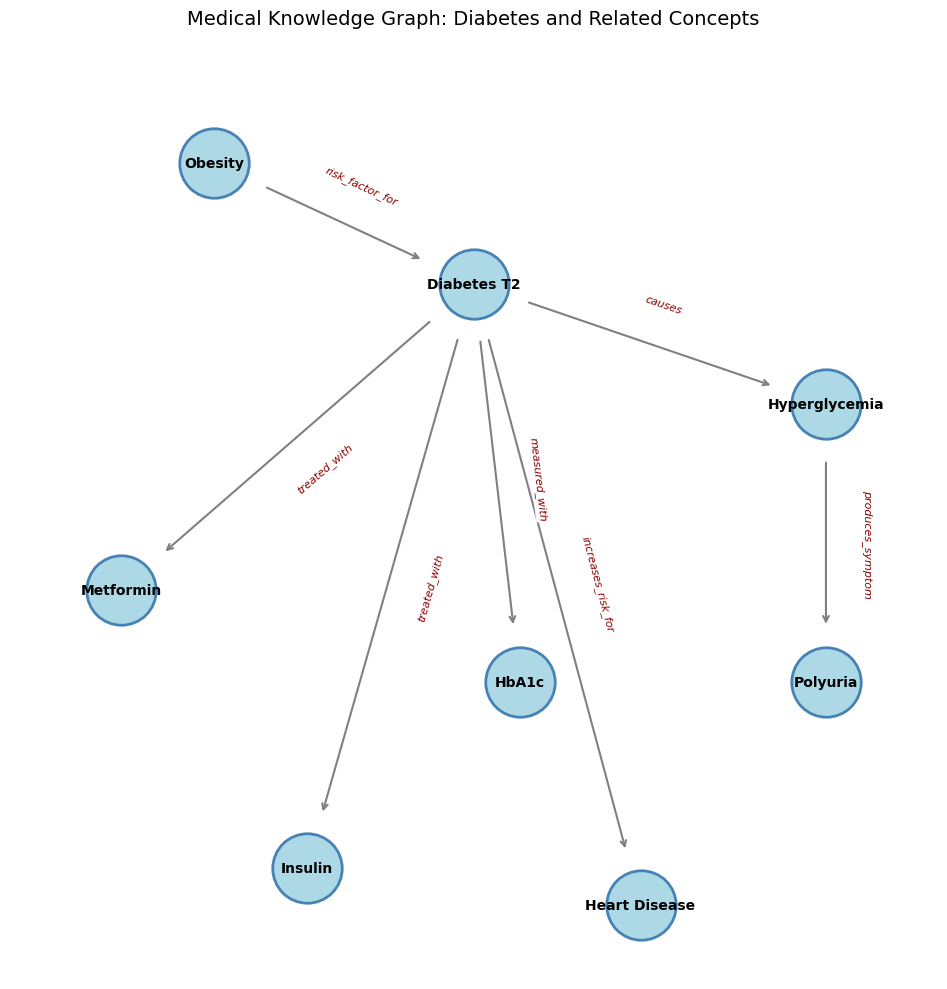

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Simple knowledge graph visualization

def draw_medical_knowledge_graph():
    """
    Draws a simple medical knowledge graph with improved readability.
    Edge annotations are placed so they don't overlap with nodes.
    """
    fig, ax = plt.subplots(figsize=(14, 10))
    
    # Define nodes (entities) - adjusted layout for better readability
    nodes = {
        'Diabetes T2': (0.5, 0.75),
        'Metformin': (0.12, 0.42),
        'Insulin': (0.32, 0.12),
        'Hyperglycemia': (0.88, 0.62),
        'Polyuria': (0.88, 0.32),
        'HbA1c': (0.55, 0.32),
        'Obesity': (0.22, 0.88),
        'Heart Disease': (0.68, 0.08)
    }
    
    # Define edges (relations)
    edges = [
        ('Diabetes T2', 'Metformin', 'treated_with'),
        ('Diabetes T2', 'Insulin', 'treated_with'),
        ('Diabetes T2', 'Hyperglycemia', 'causes'),
        ('Hyperglycemia', 'Polyuria', 'produces_symptom'),
        ('Diabetes T2', 'HbA1c', 'measured_with'),
        ('Obesity', 'Diabetes T2', 'risk_factor_for'),
        ('Diabetes T2', 'Heart Disease', 'increases_risk_for')
    ]
    
    # Draw nodes
    for name, (x, y) in nodes.items():
        ax.scatter(x, y, s=2500, c='lightblue', edgecolors='steelblue', linewidths=2, zorder=3)
        ax.annotate(name, (x, y), ha='center', va='center', fontsize=10, fontweight='bold')
    
    # Draw edges with improved label placement
    for from_node, to_node, relation in edges:
        x1, y1 = nodes[from_node]
        x2, y2 = nodes[to_node]
        
        # Calculate edge vector
        dx = x2 - x1
        dy = y2 - y1
        length = np.sqrt(dx**2 + dy**2)
        
        # Normalize direction vector
        ux, uy = dx / length, dy / length
        
        # Calculate perpendicular vector (for offset)
        px, py = -uy, ux
        
        # Adjust start and end points to avoid overlap with nodes
        node_radius = 0.06
        start_x = x1 + ux * node_radius
        start_y = y1 + uy * node_radius
        end_x = x2 - ux * node_radius
        end_y = y2 - uy * node_radius
        
        # Draw arrow
        ax.annotate('', xy=(end_x, end_y), xytext=(start_x, start_y),
                    arrowprops=dict(arrowstyle='->', color='gray', lw=1.5),
                    zorder=1)
        
        # Calculate label position along edge (midpoint, but with offset)
        label_x = (x1 + x2) / 2
        label_y = (y1 + y2) / 2
        
        # Offset label perpendicular to edge (avoid overlap)
        offset_distance = 0.045
        label_x += px * offset_distance
        label_y += py * offset_distance
        
        # Calculate rotation angle for text
        angle = np.degrees(np.arctan2(dy, dx))
        if angle > 90:
            angle -= 180
        elif angle < -90:
            angle += 180
        
        # Add relation name with rotation and white background
        ax.annotate(relation, (label_x, label_y), fontsize=8, color='darkred',
                    ha='center', va='center', style='italic',
                    rotation=angle, rotation_mode='anchor',
                    bbox=dict(boxstyle='round,pad=0.15', facecolor='white', 
                              edgecolor='none', alpha=0.9))
    
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title('Medical Knowledge Graph: Diabetes and Related Concepts', fontsize=14, pad=20)
    
    plt.tight_layout()
    plt.show()

draw_medical_knowledge_graph()

---

## 4. Medical Ontologies

Medicine has developed comprehensive ontologies - structured vocabularies with defined concepts and relations.

### Important Medical Ontologies

| Ontology | Description | Use Case |
|----------|-------------|----------|
| **SNOMED CT** | Comprehensive clinical terminology | Clinical documentation |
| **ICD-10/11** | International Classification of Diseases | Diagnosis coding |
| **LOINC** | Logical Observation Identifiers | Laboratory tests |
| **RxNorm** | Normalized drug names | Medications |
| **HPO** | Human Phenotype Ontology | Genetics/phenotypes |

### How Ontologies Strengthen AI

1. **Standardization**: Common language across systems
2. **Reasoning**: Derive new knowledge from relations
3. **Validation**: Check consistency in data
4. **Explanation**: Provide meaningful explanations

In [4]:
# Example of ontology-based reasoning

def ontology_reasoning():
    """
    Demonstrates how ontology knowledge can improve AI reasoning.
    """
    # Simulated knowledge base
    ontology = {
        "is_a": {
            "Metformin": "Antidiabetic",
            "Antidiabetic": "Medication",
            "Insulin": "Antidiabetic"
        },
        "treats": {
            "Antidiabetic": "Diabetes"
        },
        "contraindicated": {
            "Metformin": "Renal Failure"
        }
    }
    
    print("ONTOLOGY-BASED REASONING")
    print("=" * 50)
    
    # Reasoning: "Does Metformin treat diabetes?"
    print("\nQuestion: Does Metformin treat diabetes?")
    print("\nReasoning:")
    print("  1. Metformin IS_A Antidiabetic")
    print("  2. Antidiabetic TREATS Diabetes")
    print("  → Conclusion: YES, Metformin treats Diabetes")
    
    print("\n" + "-"*50)
    
    # Reasoning with contraindication
    print("\nQuestion: Can a patient with renal failure use Metformin?")
    print("\nReasoning:")
    print("  1. Metformin CONTRAINDICATED Renal Failure")
    print("  → Conclusion: NO, contraindicated in renal failure")
    print("  → WARNING: Consider alternative (e.g., Insulin)")

ontology_reasoning()

ONTOLOGY-BASED REASONING

Question: Does Metformin treat diabetes?

Reasoning:
  1. Metformin IS_A Antidiabetic
  2. Antidiabetic TREATS Diabetes
  → Conclusion: YES, Metformin treats Diabetes

--------------------------------------------------

Question: Can a patient with renal failure use Metformin?

Reasoning:
  1. Metformin CONTRAINDICATED Renal Failure
  → Conclusion: NO, contraindicated in renal failure
  → WARNING: Consider alternative (e.g., Insulin)


---

## 5. Applications in Medicine

### Examples of Neurosymbolic AI in Healthcare

**1. Diagnosis Support with Explanation**
- Neural: Classifies symptoms
- Symbolic: Explains via medical ontology

**2. Drug Interactions**
- Neural: Predicts interaction risk
- Symbolic: Verifies against pharmacological knowledge

**3. Clinical Decision Support**
- Neural: Risk stratification from data
- Symbolic: Checks against clinical guidelines

**4. Biobank Analysis**
- Neural: Finds patterns in genomic data
- Symbolic: Links to phenotype ontology

In [5]:
# Example: Hybrid diagnosis system

def hybrid_diagnosis_system(symptoms):
    """
    Simulates a neurosymbolic diagnosis system.
    """
    print("HYBRID DIAGNOSIS SYSTEM")
    print("=" * 60)
    print(f"Input symptoms: {symptoms}")
    print()
    
    # Step 1: Neural component (simulated)
    print("STEP 1: Neural analysis")
    print("-" * 40)
    neural_predictions = {
        "Diabetes mellitus": 0.75,
        "Hyperthyroidism": 0.15,
        "Kidney disease": 0.10
    }
    for diagnosis, prob in neural_predictions.items():
        print(f"  {diagnosis}: {prob:.0%}")
    
    print()
    
    # Step 2: Symbolic validation
    print("STEP 2: Symbolic validation (ontology check)")
    print("-" * 40)
    print("  Check: 'Polyuria' is known symptom of 'Diabetes'? ✓")
    print("  Check: 'Weight loss' is known symptom of 'Diabetes'? ✓")
    print("  Check: 'Thirst' is known symptom of 'Diabetes'? ✓")
    print("  → All symptoms are ontologically consistent with Diabetes")
    
    print()
    
    # Step 3: Combined output
    print("STEP 3: Explanation to clinician")
    print("-" * 40)
    print("""  RECOMMENDATION: Consider Diabetes mellitus (75% probability)
  
  RATIONALE:
  - Neural model identified pattern consistent with diabetes
  - Symptoms (polyuria, weight loss, thirst) are all classic
    diabetes symptoms according to SNOMED CT
  
  RECOMMENDED INVESTIGATION:
  - Fasting blood glucose
  - HbA1c
  """)

# Test
hybrid_diagnosis_system(["polyuria", "weight loss", "increased thirst"])

HYBRID DIAGNOSIS SYSTEM
Input symptoms: ['polyuria', 'weight loss', 'increased thirst']

STEP 1: Neural analysis
----------------------------------------
  Diabetes mellitus: 75%
  Hyperthyroidism: 15%
  Kidney disease: 10%

STEP 2: Symbolic validation (ontology check)
----------------------------------------
  Check: 'Polyuria' is known symptom of 'Diabetes'? ✓
  Check: 'Weight loss' is known symptom of 'Diabetes'? ✓
  Check: 'Thirst' is known symptom of 'Diabetes'? ✓
  → All symptoms are ontologically consistent with Diabetes

STEP 3: Explanation to clinician
----------------------------------------
  RECOMMENDATION: Consider Diabetes mellitus (75% probability)
  
  RATIONALE:
  - Neural model identified pattern consistent with diabetes
  - Symptoms (polyuria, weight loss, thirst) are all classic
    diabetes symptoms according to SNOMED CT
  
  RECOMMENDED INVESTIGATION:
  - Fasting blood glucose
  - HbA1c
  


---

## 6. Case Study: Neurosymbolic AI for Brain Tumors (Glioma) <a id="6-case-study-brain-tumors"></a>

### Motivation

Brain tumors, especially **gliomas**, represent an ideal application area for neurosymbolic AI:

1. **Complex classification**: The WHO classification of CNS tumors (2021) combines histological and molecular criteria in a hierarchical system
2. **Rich domain knowledge**: Comprehensive ontologies and knowledge graphs exist for neuro-oncology
3. **Critical decisions**: Treatment choices require reliable, explainable AI
4. **Multimodal data**: Imaging diagnostics (MRI), genetics, histopathology, and clinical data must be integrated

### WHO 2021 CNS Tumor Classification

The new WHO classification represents a paradigm shift where **molecular markers** are integrated into the diagnosis:

| Tumor Type | Key Markers | Significance |
|-----------|----------------|-----------|
| **Glioblastoma, IDH-wildtype** | IDH-wildtype, +7/-10, TERT | Most aggressive, grade 4 |
| **Astrocytoma, IDH-mutant** | IDH-mutant, ATRX loss | Grade 2-4 |
| **Oligodendroglioma, IDH-mutant** | IDH-mutant, 1p/19q co-deleted | Better prognosis |
| **Diffuse midline glioma** | H3 K27M-mutant | Children, poor prognosis |

### Dataset: BraTS Challenge

[Brain Tumor Segmentation (BraTS) Challenge](https://www.synapse.org/brats) is an annual competition that provides:
- **Multiparametric MRI** (T1, T1Gd, T2, FLAIR)
- **Segmentation masks** (enhancing tumor, edema, necrosis)
- **Clinical data** and survival times

In this case study, we demonstrate how neurosymbolic AI can:
1. Build a **knowledge graph** for glioma classification
2. Combine **neural predictions** from image analysis with **symbolic reasoning**
3. Provide **explainable** and **verifiable** treatment recommendations

In [6]:
# ============================================================================
# NEUROSYMBOLIC AI FOR GLIOMA: Complete implementation
# ============================================================================

import numpy as np
import pandas as pd
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple, Set
from enum import Enum
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# PART 1: ONTOLOGY AND KNOWLEDGE GRAPH FOR GLIOMA
# ============================================================================

class WHOGrade(Enum):
    """WHO grading of CNS tumors"""
    GRAD_1 = 1
    GRAD_2 = 2
    GRAD_3 = 3
    GRAD_4 = 4

class IDHStatus(Enum):
    """IDH mutation status"""
    WILDTYPE = "IDH-wildtype"
    MUTANT = "IDH-mutant"
    UNKNOWN = "IDH-unknown"

class MGMTStatus(Enum):
    """MGMT promoter methylation status"""
    METHYLATED = "MGMT-methylated"
    UNMETHYLATED = "MGMT-unmethylated"
    UNKNOWN = "MGMT-unknown"

@dataclass
class MolecularProfile:
    """Molecular markers for glioma"""
    idh_status: IDHStatus
    mgmt_status: MGMTStatus
    codeletion_1p19q: bool = False
    atrx_loss: bool = False
    tert_promoter: bool = False
    egfr_amplification: bool = False
    chromosome_7_gain: bool = False
    chromosome_10_loss: bool = False
    h3_k27m: bool = False
    
    def has_glioblastoma_profile(self) -> bool:
        """Check if profile matches glioblastoma criteria"""
        return (self.idh_status == IDHStatus.WILDTYPE and
                (self.tert_promoter or self.egfr_amplification or
                 (self.chromosome_7_gain and self.chromosome_10_loss)))

@dataclass
class MRIFeatures:
    """Quantitative MRI features from image analysis"""
    tumor_volume_ml: float
    enhancing_volume_ml: float
    necrosis_volume_ml: float
    edema_volume_ml: float
    enhancing_ratio: float = 0.0
    location: str = "unknown"
    crosses_midline: bool = False
    involves_eloquent: bool = False
    
    def __post_init__(self):
        if self.tumor_volume_ml > 0:
            self.enhancing_ratio = self.enhancing_volume_ml / self.tumor_volume_ml

@dataclass
class ClinicalProfile:
    """Clinical data for the patient"""
    age: int
    karnofsky_score: int  # 0-100
    symptom_duration_weeks: int
    resection_status: str = "unknown"  # GTR, STR, biopsy
    previous_treatment: List[str] = field(default_factory=list)

@dataclass
class GliomaPatient:
    """Complete patient profile for glioma"""
    patient_id: str
    molecular: MolecularProfile
    mri: MRIFeatures
    clinical: ClinicalProfile
    histology: str = "unknown"

print("✓ Ontology and data classes for glioma are defined")
print(f"  - WHOGrade: {[g.name for g in WHOGrade]}")
print(f"  - IDHStatus: {[s.value for s in IDHStatus]}")
print(f"  - MGMTStatus: {[s.value for s in MGMTStatus]}")

✓ Ontology and data classes for glioma are defined
  - WHOGrade: ['GRAD_1', 'GRAD_2', 'GRAD_3', 'GRAD_4']
  - IDHStatus: ['IDH-wildtype', 'IDH-mutant', 'IDH-unknown']
  - MGMTStatus: ['MGMT-methylated', 'MGMT-unmethylated', 'MGMT-unknown']


In [7]:
# ============================================================================
# PART 2: KNOWLEDGE GRAPH FOR GLIOMA (Symbolic component)
# ============================================================================

class GliomaKnowledgeGraph:
    """
    Knowledge graph representing WHO 2021 CNS classification.
    This is the SYMBOLIC component of our neurosymbolic system.
    """
    
    def __init__(self):
        # Entities (nodes)
        self.tumor_types = {
            "glioblastoma": {
                "name": "Glioblastoma, IDH-wildtype",
                "grade": WHOGrade.GRAD_4,
                "median_survival_months": 15,
                "description": "Most aggressive primary brain tumor in adults"
            },
            "astrocytoma_2": {
                "name": "Astrocytoma, IDH-mutant, grade 2",
                "grade": WHOGrade.GRAD_2,
                "median_survival_months": 96,
                "description": "Diffusely infiltrating astrocytoma with relatively good prognosis"
            },
            "astrocytoma_3": {
                "name": "Astrocytoma, IDH-mutant, grade 3",
                "grade": WHOGrade.GRAD_3,
                "median_survival_months": 60,
                "description": "Anaplastic astrocytoma with increased mitotic activity"
            },
            "astrocytoma_4": {
                "name": "Astrocytoma, IDH-mutant, grade 4",
                "grade": WHOGrade.GRAD_4,
                "median_survival_months": 36,
                "description": "High-grade IDH-mutant astrocytoma with necrosis/microvascular proliferation"
            },
            "oligodendroglioma_2": {
                "name": "Oligodendroglioma, IDH-mutant, 1p/19q co-deleted, grade 2",
                "grade": WHOGrade.GRAD_2,
                "median_survival_months": 156,
                "description": "Well-differentiated oligodendroglioma with favorable prognosis"
            },
            "oligodendroglioma_3": {
                "name": "Oligodendroglioma, IDH-mutant, 1p/19q co-deleted, grade 3",
                "grade": WHOGrade.GRAD_3,
                "median_survival_months": 114,
                "description": "Anaplastic oligodendroglioma"
            },
            "dmg": {
                "name": "Diffuse midline glioma, H3 K27M-mutant",
                "grade": WHOGrade.GRAD_4,
                "median_survival_months": 11,
                "description": "Aggressive pediatric tumor in brainstem/thalamus"
            }
        }
        
        # Relations (edges)
        self.classification_rules = self._build_classification_rules()
        self.treatment_rules = self._build_treatment_rules()
        self.prognostic_factors = self._build_prognostic_factors()
    
    def _build_classification_rules(self) -> Dict:
        """WHO 2021 classification rules as logical conditions"""
        return {
            "glioblastoma": {
                "requirements": [
                    ("idh_status", "==", IDHStatus.WILDTYPE),
                    ("histology", "in", ["glioblastoma", "high_grade_glioma"]),
                ],
                "or_molecular": [
                    ("tert_promoter", "==", True),
                    ("egfr_amplification", "==", True),
                    (("chromosome_7_gain", "==", True), ("chromosome_10_loss", "==", True))
                ]
            },
            "oligodendroglioma": {
                "requirements": [
                    ("idh_status", "==", IDHStatus.MUTANT),
                    ("codeletion_1p19q", "==", True)
                ]
            },
            "astrocytoma_idh_mutant": {
                "requirements": [
                    ("idh_status", "==", IDHStatus.MUTANT),
                    ("codeletion_1p19q", "==", False),
                    ("atrx_loss", "==", True)
                ]
            },
            "dmg": {
                "requirements": [
                    ("h3_k27m", "==", True),
                    ("location", "in", ["pons", "thalamus", "midline"])
                ]
            }
        }
    
    def _build_treatment_rules(self) -> Dict:
        """Treatment recommendations based on tumor type and molecular profile"""
        return {
            "glioblastoma": {
                "standard": ["Maximal safe resection", "Temozolomide + radiation (Stupp protocol)"],
                "mgmt_methylated": ["Temozolomide has increased efficacy", "Tumor Treating Fields (TTFields) considered"],
                "mgmt_unmethylated": ["Consider alternative to temozolomide", "Clinical trials recommended"],
                "elderly_patient": ["Hypofractionated radiation", "Temozolomide monotherapy if MGMT-methylated"]
            },
            "astrocytoma_idh_mutant": {
                "grade_2": ["Observation vs. early treatment", "Resection upon progression"],
                "grade_3_4": ["Resection + radiation + chemotherapy", "PCV or temozolomide"],
                "vorasidenib": ["IDH inhibitor (approved 2024) for low-grade"]
            },
            "oligodendroglioma": {
                "grade_2": ["Maximal safe resection", "Radiation + PCV at high risk"],
                "grade_3": ["Resection + radiation + PCV", "Temozolomide as alternative"]
            },
            "dmg": {
                "standard": ["Radiation (palliative)", "No standard chemotherapy effective"],
                "clinical_trials": ["ONC201", "CAR-T therapy"]
            }
        }
    
    def _build_prognostic_factors(self) -> Dict:
        """Prognostic factors with evidence level"""
        return {
            "positive": [
                ("IDH mutation", "strong", "Significantly better prognosis"),
                ("1p/19q co-deletion", "strong", "Better response to chemotherapy"),
                ("MGMT methylation", "strong", "Better response to temozolomide"),
                ("Young age (<40)", "moderate", "Better treatment tolerance"),
                ("High Karnofsky (>70)", "strong", "Better functional status"),
                ("Gross total resection", "strong", "Increased progression-free survival")
            ],
            "negative": [
                ("IDH-wildtype", "strong", "Shorter survival"),
                ("TERT promoter mutation", "moderate", "Aggressive biology"),
                ("EGFR amplification", "moderate", "Glioblastoma-associated"),
                ("Age >65", "moderate", "Reduced treatment tolerance"),
                ("Low Karnofsky (<70)", "strong", "Poorer outcome"),
                ("Multifocal tumor", "moderate", "Not candidate for resection")
            ]
        }
    
    def classify_tumor(self, patient: GliomaPatient) -> Tuple[str, Dict]:
        """
        Classify tumor based on WHO 2021 criteria.
        Returns tuple of (tumor_type, explanation_dict)
        """
        mol = patient.molecular
        explanation = {"applied_rules": [], "conclusion": "", "uncertainty": []}
        
        # Check H3 K27M first (has high priority)
        if mol.h3_k27m:
            explanation["applied_rules"].append("H3 K27M mutation detected → Diffuse midline glioma")
            return "dmg", explanation
        
        # Check IDH status
        if mol.idh_status == IDHStatus.WILDTYPE:
            explanation["applied_rules"].append("IDH-wildtype detected")
            
            # Check for glioblastoma criteria
            gbm_criteria = []
            if mol.tert_promoter:
                gbm_criteria.append("TERT promoter mutation")
            if mol.egfr_amplification:
                gbm_criteria.append("EGFR amplification")
            if mol.chromosome_7_gain and mol.chromosome_10_loss:
                gbm_criteria.append("+7/-10 chromosome changes")
            
            if gbm_criteria:
                explanation["applied_rules"].append(f"Glioblastoma markers: {', '.join(gbm_criteria)}")
                explanation["conclusion"] = "Glioblastoma, IDH-wildtype, grade 4"
                return "glioblastoma", explanation
            else:
                explanation["uncertainty"].append("No specific GBM markers, but IDH-wildtype")
                explanation["conclusion"] = "Probable glioblastoma (requires histology)"
                return "glioblastoma", explanation
        
        elif mol.idh_status == IDHStatus.MUTANT:
            explanation["applied_rules"].append("IDH mutation detected")
            
            # Check for oligodendroglioma
            if mol.codeletion_1p19q:
                explanation["applied_rules"].append("1p/19q co-deletion detected → Oligodendroglioma")
                # Grading based on histology/MRI
                if patient.mri.necrosis_volume_ml > 0 or patient.mri.enhancing_ratio > 0.3:
                    explanation["conclusion"] = "Oligodendroglioma, grade 3"
                    return "oligodendroglioma_3", explanation
                else:
                    explanation["conclusion"] = "Oligodendroglioma, grade 2"
                    return "oligodendroglioma_2", explanation
            
            # Astrocytoma
            else:
                explanation["applied_rules"].append("No 1p/19q co-deletion → Astrocytoma")
                if mol.atrx_loss:
                    explanation["applied_rules"].append("ATRX loss confirms astrocytoma lineage")
                
                # Grading
                if patient.mri.necrosis_volume_ml > 0:
                    explanation["conclusion"] = "Astrocytoma, IDH-mutant, grade 4"
                    return "astrocytoma_4", explanation
                elif patient.mri.enhancing_ratio > 0.3:
                    explanation["conclusion"] = "Astrocytoma, IDH-mutant, grade 3"
                    return "astrocytoma_3", explanation
                else:
                    explanation["conclusion"] = "Astrocytoma, IDH-mutant, grade 2"
                    return "astrocytoma_2", explanation
        
        # Unknown IDH
        explanation["uncertainty"].append("IDH status unknown - classification uncertain")
        return "unknown", explanation
    
    def generate_treatment_recommendation(self, patient: GliomaPatient, 
                                       tumor_type: str) -> Dict:
        """
        Generate treatment recommendation based on symbolic reasoning.
        """
        recommendation = {
            "primary_treatment": [],
            "additional_treatment": [],
            "prognostic_comments": [],
            "recommended_studies": []
        }
        
        rules = self.treatment_rules.get(tumor_type, {})
        
        # Standard treatment
        if "standard" in rules:
            recommendation["primary_treatment"].extend(rules["standard"])
        
        # MGMT stratification
        if patient.molecular.mgmt_status == MGMTStatus.METHYLATED:
            if "mgmt_methylated" in rules:
                recommendation["additional_treatment"].extend(rules["mgmt_methylated"])
            recommendation["prognostic_comments"].append(
                "MGMT-methylated: Expected better response to temozolomide"
            )
        elif patient.molecular.mgmt_status == MGMTStatus.UNMETHYLATED:
            if "mgmt_unmethylated" in rules:
                recommendation["additional_treatment"].extend(rules["mgmt_unmethylated"])
        
        # Age-specific recommendations
        if patient.clinical.age >= 65 and "elderly_patient" in rules:
            recommendation["additional_treatment"].extend(rules["elderly_patient"])
        
        # IDH-mutant specific
        if tumor_type.startswith("astrocytoma") and "vorasidenib" in rules:
            if patient.molecular.idh_status == IDHStatus.MUTANT:
                recommendation["recommended_studies"].append(
                    "Vorasidenib (IDH inhibitor) approved for low-grade IDH-mutant gliomas"
                )
        
        return recommendation

# Initialize knowledge graph
kg = GliomaKnowledgeGraph()
print("✓ Glioma knowledge graph initialized")
print(f"  - {len(kg.tumor_types)} tumor types defined")
print(f"  - {len(kg.classification_rules)} classification rules")
print(f"  - Treatment rules for {len(kg.treatment_rules)} tumor types")

✓ Glioma knowledge graph initialized
  - 7 tumor types defined
  - 4 classification rules
  - Treatment rules for 4 tumor types


In [8]:
# ============================================================================
# PART 3: NEURAL COMPONENT - Simulated deep learning model for MRI analysis
# ============================================================================

class NeuralGliomaAnalysis:
    """
    Simulates a deep learning model (e.g., 3D U-Net) for MRI analysis.
    In practice, this would be a trained CNN on BraTS data.
    
    This is the NEURAL component of our neurosymbolic system.
    """
    
    def __init__(self):
        """
        Simulates a pre-trained model.
        In reality: self.model = load_trained_model('brats_unet.h5')
        """
        self.model_name = "nnU-Net (BraTS 2023)"
        self.input_modalities = ["T1", "T1Gd", "T2", "FLAIR"]
        self.output_classes = ["background", "enhancing", "edema", "necrosis"]
        
        # Simulated model performance metrics (from BraTS Challenge)
        self.dice_scores = {
            "enhancing": 0.82,
            "whole_tumor": 0.91,
            "tumor_core": 0.86
        }
    
    def segment_tumor(self, mri_data: dict) -> MRIFeatures:
        """
        Simulates tumor segmentation from MRI.
        
        In practice:
        - Input: 4D array (T1, T1Gd, T2, FLAIR)
        - Output: Segmentation mask + quantitative features
        """
        # Simulates output from segmentation network
        np.random.seed(42)  # For reproducibility
        
        # Simulated volumetric measurements (ml)
        tumor_volume = np.random.uniform(20, 120)
        enhancing = np.random.uniform(5, tumor_volume * 0.4)
        necrosis = np.random.uniform(0, tumor_volume * 0.2)
        edema = np.random.uniform(10, tumor_volume * 0.8)
        
        return MRIFeatures(
            tumor_volume_ml=round(tumor_volume, 1),
            enhancing_volume_ml=round(enhancing, 1),
            necrosis_volume_ml=round(necrosis, 1),
            edema_volume_ml=round(edema, 1),
            location=np.random.choice(["frontal", "temporal", "parietal", "occipital"]),
            crosses_midline=np.random.choice([True, False]),
            involves_eloquent=np.random.choice([True, False], p=[0.3, 0.7])
        )
    
    def predict_molecular_status(self, mri_features: MRIFeatures) -> Dict:
        """
        Predicts molecular status from MRI (radiogenomics).
        
        Recent research shows that certain MRI features correlate with:
        - IDH mutation status
        - MGMT methylation
        - 1p/19q co-deletion
        """
        # Set seed for reproducibility
        np.random.seed(42)
        
        # Simulated predictions with uncertainty
        predictions = {}
        
        # IDH prediction (higher enhancing ratio → more likely wildtype)
        if mri_features.enhancing_ratio > 0.3:
            idh_wildtype_prob = 0.75 + np.random.uniform(-0.1, 0.1)
        else:
            idh_wildtype_prob = 0.35 + np.random.uniform(-0.1, 0.1)
        
        predictions["idh_wildtype"] = {
            "probability": round(idh_wildtype_prob, 2),
            "confidence_interval": (round(idh_wildtype_prob - 0.15, 2), 
                                    round(idh_wildtype_prob + 0.15, 2)),
            "model_uncertainty": "moderate"
        }
        
        # MGMT prediction
        mgmt_methylated_prob = 0.45 + np.random.uniform(-0.15, 0.15)
        predictions["mgmt_methylated"] = {
            "probability": round(mgmt_methylated_prob, 2),
            "confidence_interval": (round(mgmt_methylated_prob - 0.2, 2),
                                    round(mgmt_methylated_prob + 0.2, 2)),
            "model_uncertainty": "high"  # MGMT is difficult to predict from MRI
        }
        
        # Survival estimate
        if mri_features.necrosis_volume_ml > 10:
            median_os = 12 + np.random.uniform(-3, 3)
        elif mri_features.enhancing_ratio > 0.3:
            median_os = 18 + np.random.uniform(-4, 4)
        else:
            median_os = 36 + np.random.uniform(-6, 6)
        
        predictions["survival"] = {
            "median_months": round(median_os, 0),
            "95_ci": (round(median_os - 6, 0), round(median_os + 8, 0)),
            "model": "Cox proportional hazards + Deep Surv"
        }
        
        return predictions
    
    def calculate_uncertainty(self, predictions: Dict) -> Dict:
        """
        Calculates epistemic uncertainty (model uncertainty) via Monte Carlo Dropout.
        """
        uncertainty = {
            "type": "epistemic",
            "method": "MC Dropout (100 forward passes)",
            "assessment": {}
        }
        
        for key, pred in predictions.items():
            if isinstance(pred, dict) and "model_uncertainty" in pred:
                uncertainty["assessment"][key] = pred["model_uncertainty"]
        
        return uncertainty

# Initialize neural analyzer
neural_model = NeuralGliomaAnalysis()
print("✓ Neural analyzer initialized")
print(f"  - Model: {neural_model.model_name}")
print(f"  - Dice scores: ET={neural_model.dice_scores['enhancing']:.2f}, "
      f"WT={neural_model.dice_scores['whole_tumor']:.2f}")

✓ Neural analyzer initialized
  - Model: nnU-Net (BraTS 2023)
  - Dice scores: ET=0.82, WT=0.91


In [9]:
# ============================================================================
# PART 4: NEUROSYMBOLIC INTEGRATION - Hybrid reasoning
# ============================================================================

class NeurosymbolicGliomaSystem:
    """
    Integrates neural image analysis with symbolic medical knowledge.
    
    The flow is:
    1. NEURAL: MRI → Segmentation → Quantitative features → Molecular prediction
    2. SYMBOLIC: Features + Prediction → Ontology matching → Classification
    3. SYMBOLIC: Classification → Treatment rules → Recommendation
    4. HYBRID: Uncertainty quantification → Explanation
    """
    
    def __init__(self, knowledge_graph: GliomaKnowledgeGraph,
                 neural_model: NeuralGliomaAnalysis):
        self.kg = knowledge_graph
        self.nn = neural_model
        
    def analyze_patient(self, patient: GliomaPatient, 
                          verify_molecular: bool = True) -> Dict:
        """
        Complete neurosymbolic analysis of a glioma patient.
        """
        result = {
            "patient_id": patient.patient_id,
            "neural_analysis": {},
            "symbolic_classification": {},
            "hybrid_validation": {},
            "treatment_recommendation": {},
            "explanation": {}
        }
        
        # ==== STEP 1: Neural analysis ====
        print(f"\n{'='*60}")
        print(f"NEUROSYMBOLIC ANALYSIS: Patient {patient.patient_id}")
        print(f"{'='*60}")
        
        print("\n[STEP 1] NEURAL COMPONENT: MRI analysis")
        print("-" * 40)
        
        # Use patient's MRI features (in practice: segment from raw MRI)
        mri = patient.mri
        print(f"  Tumor volume: {mri.tumor_volume_ml} ml")
        print(f"  Enhancing: {mri.enhancing_volume_ml} ml ({mri.enhancing_ratio:.1%})")
        print(f"  Necrosis: {mri.necrosis_volume_ml} ml")
        print(f"  Edema: {mri.edema_volume_ml} ml")
        print(f"  Location: {mri.location}")
        
        # Radiogenomics predictions
        predictions = self.nn.predict_molecular_status(mri)
        result["neural_analysis"]["mri_features"] = {
            "tumor_volume": mri.tumor_volume_ml,
            "enhancing_ratio": round(mri.enhancing_ratio, 2),
            "has_necrosis": mri.necrosis_volume_ml > 0
        }
        result["neural_analysis"]["molecular_prediction"] = predictions
        
        print(f"\n  Radiogenomics predictions:")
        print(f"    IDH-wildtype: {predictions['idh_wildtype']['probability']:.0%} "
              f"(uncertainty: {predictions['idh_wildtype']['model_uncertainty']})")
        print(f"    MGMT-methylated: {predictions['mgmt_methylated']['probability']:.0%} "
              f"(uncertainty: {predictions['mgmt_methylated']['model_uncertainty']})")
        
        # ==== STEP 2: Symbolic classification ====
        print("\n[STEP 2] SYMBOLIC COMPONENT: WHO classification")
        print("-" * 40)
        
        tumor_type, explanation = self.kg.classify_tumor(patient)
        result["symbolic_classification"]["tumor_type"] = tumor_type
        result["symbolic_classification"]["explanation"] = explanation
        
        print(f"  Applied rules:")
        for rule in explanation["applied_rules"]:
            print(f"    → {rule}")
        print(f"  Conclusion: {explanation['conclusion']}")
        
        if explanation["uncertainty"]:
            print(f"  ⚠ Uncertainty: {'; '.join(explanation['uncertainty'])}")
        
        # ==== STEP 3: Hybrid validation ====
        print("\n[STEP 3] HYBRID VALIDATION: Consistency check")
        print("-" * 40)
        
        validation = self._validate_consistency(patient, predictions, tumor_type)
        result["hybrid_validation"] = validation
        
        if validation["consistent"]:
            print(f"  ✓ Neural predictions are CONSISTENT with symbolic classification")
        else:
            print(f"  ⚠ INCONSISTENCY detected:")
            for warning in validation["warnings"]:
                print(f"    → {warning}")
        
        # ==== STEP 4: Treatment recommendation ====
        print("\n[STEP 4] TREATMENT RECOMMENDATION: Rule-based")
        print("-" * 40)
        
        treatment = self.kg.generate_treatment_recommendation(patient, tumor_type)
        result["treatment_recommendation"] = treatment
        
        print(f"  Primary treatment:")
        for tr in treatment["primary_treatment"]:
            print(f"    • {tr}")
        
        if treatment["additional_treatment"]:
            print(f"  Additional treatment (based on molecular profile):")
            for tr in treatment["additional_treatment"]:
                print(f"    • {tr}")
        
        if treatment["prognostic_comments"]:
            print(f"  Prognostic comments:")
            for comment in treatment["prognostic_comments"]:
                print(f"    → {comment}")
        
        # ==== STEP 5: Generated explanation ====
        print("\n[STEP 5] EXPLANATION FOR CLINICIAN")
        print("-" * 40)
        
        explanation_text = self._generate_explanation(patient, result)
        result["explanation"]["text"] = explanation_text
        print(explanation_text)
        
        return result
    
    def _validate_consistency(self, patient: GliomaPatient, 
                             neural_pred: Dict, 
                             tumor_type: str) -> Dict:
        """
        Checks consistency between neural predictions and symbolic classification.
        This is the CORE of neurosymbolic AI: using symbolic knowledge to 
        validate neural output.
        """
        validation = {"consistent": True, "warnings": [], "confirmations": []}
        
        # Get actual molecular status
        actual_idh = patient.molecular.idh_status
        predicted_idh_wildtype_prob = neural_pred["idh_wildtype"]["probability"]
        
        # Check IDH consistency
        if actual_idh == IDHStatus.WILDTYPE:
            if predicted_idh_wildtype_prob < 0.5:
                validation["consistent"] = False
                validation["warnings"].append(
                    f"Neural model predicts IDH-mutant ({1-predicted_idh_wildtype_prob:.0%}), "
                    f"but actual status is IDH-wildtype"
                )
            else:
                validation["confirmations"].append("IDH prediction matches actual status")
        
        elif actual_idh == IDHStatus.MUTANT:
            if predicted_idh_wildtype_prob > 0.5:
                validation["consistent"] = False
                validation["warnings"].append(
                    f"Neural model predicts IDH-wildtype ({predicted_idh_wildtype_prob:.0%}), "
                    f"but actual status is IDH-mutant"
                )
            else:
                validation["confirmations"].append("IDH prediction matches actual status")
        
        # Check MRI features against tumor type (ontology-based validation)
        if tumor_type == "glioblastoma":
            if patient.mri.enhancing_ratio < 0.1:
                validation["warnings"].append(
                    "Low enhancing ratio (<10%) is unusual for glioblastoma - consider diagnosis"
                )
        
        if tumor_type in ["astrocytoma_2", "oligodendroglioma_2"]:
            if patient.mri.necrosis_volume_ml > 5:
                validation["consistent"] = False
                validation["warnings"].append(
                    "Necrosis detected, but classified as grade 2 - upgrade to grade 3/4"
                )
        
        return validation
    
    def _generate_explanation(self, patient: GliomaPatient, result: Dict) -> str:
        """
        Generates a human-readable explanation of the analysis.
        """
        tumor_type = result["symbolic_classification"]["tumor_type"]
        tumor_info = self.kg.tumor_types.get(tumor_type, {})
        
        explanation = f"""
SUMMARY FOR PATIENT {patient.patient_id}:

DIAGNOSIS: {tumor_info.get('name', tumor_type.upper())}
  - WHO grade: {tumor_info.get('grade', 'unknown').name if hasattr(tumor_info.get('grade'), 'name') else 'unknown'}
  - Median survival: {tumor_info.get('median_survival_months', 'unknown')} months

MOLECULAR PROFILE:
  - IDH status: {patient.molecular.idh_status.value}
  - MGMT status: {patient.molecular.mgmt_status.value}
  - 1p/19q co-deletion: {'Yes' if patient.molecular.codeletion_1p19q else 'No'}

CLINICAL:
  - Age: {patient.clinical.age} years
  - Karnofsky: {patient.clinical.karnofsky_score}

VALIDATION: {'Consistent' if result['hybrid_validation']['consistent'] else 'See warnings above'}
"""
        return explanation

# Initialize the neurosymbolic system
ns_system = NeurosymbolicGliomaSystem(kg, neural_model)
print("✓ Neurosymbolic glioma system initialized")
print("  - Knowledge graph: WHO 2021 CNS classification")
print("  - Neural model: nnU-Net + Radiogenomics")
print("  - Integration: Hybrid validation active")

✓ Neurosymbolic glioma system initialized
  - Knowledge graph: WHO 2021 CNS classification
  - Neural model: nnU-Net + Radiogenomics
  - Integration: Hybrid validation active


### Demonstration: Analysis of Glioma Patients

We now demonstrate the neurosymbolic system on three typical patient cases:

1. **Patient A**: Classic glioblastoma (IDH-wildtype, elderly patient)
2. **Patient B**: Oligodendroglioma (IDH-mutant, 1p/19q co-deleted)
3. **Patient C**: Astrocytoma with inconsistency between MRI and molecular profile

This illustrates how the system:
- Combines neural predictions with symbolic classification
- Detects inconsistencies between data sources
- Generates explainable treatment recommendations

In [10]:
# ============================================================================
# DEMONSTRATION: Three Patient Cases
# ============================================================================

# --- PATIENT A: Classic glioblastoma ---
patient_a = GliomaPatient(
    patient_id="GBM-001",
    molecular=MolecularProfile(
        idh_status=IDHStatus.WILDTYPE,
        mgmt_status=MGMTStatus.UNMETHYLATED,
        tert_promoter=True,
        egfr_amplification=True,
        chromosome_7_gain=True,
        chromosome_10_loss=True
    ),
    mri=MRIFeatures(
        tumor_volume_ml=65.3,
        enhancing_volume_ml=28.7,
        necrosis_volume_ml=12.4,
        edema_volume_ml=45.2,
        location="temporal",
        crosses_midline=False,
        involves_eloquent=True
    ),
    clinical=ClinicalProfile(
        age=68,
        karnofsky_score=70,
        symptom_duration_weeks=4,
        resection_status="STR"  # Subtotal resection
    ),
    histology="glioblastoma"
)

# Run analysis
result_a = ns_system.analyze_patient(patient_a)


NEUROSYMBOLIC ANALYSIS: Patient GBM-001

[STEP 1] NEURAL COMPONENT: MRI analysis
----------------------------------------
  Tumor volume: 65.3 ml
  Enhancing: 28.7 ml (44.0%)
  Necrosis: 12.4 ml
  Edema: 45.2 ml
  Location: temporal

  Radiogenomics predictions:
    IDH-wildtype: 72% (uncertainty: moderate)
    MGMT-methylated: 59% (uncertainty: high)

[STEP 2] SYMBOLIC COMPONENT: WHO classification
----------------------------------------
  Applied rules:
    → IDH-wildtype detected
    → Glioblastoma markers: TERT promoter mutation, EGFR amplification, +7/-10 chromosome changes
  Conclusion: Glioblastoma, IDH-wildtype, grade 4

[STEP 3] HYBRID VALIDATION: Consistency check
----------------------------------------
  ✓ Neural predictions are CONSISTENT with symbolic classification

[STEP 4] TREATMENT RECOMMENDATION: Rule-based
----------------------------------------
  Primary treatment:
    • Maximal safe resection
    • Temozolomide + radiation (Stupp protocol)
  Additional treatmen

In [11]:
# --- PATIENT B: Oligodendroglioma with favorable prognosis ---
patient_b = GliomaPatient(
    patient_id="OLIGO-042",
    molecular=MolecularProfile(
        idh_status=IDHStatus.MUTANT,
        mgmt_status=MGMTStatus.METHYLATED,
        codeletion_1p19q=True,  # Pathognomonic for oligodendroglioma
        atrx_loss=False  # ATRX is preserved in oligodendroglioma
    ),
    mri=MRIFeatures(
        tumor_volume_ml=32.1,
        enhancing_volume_ml=3.2,  # Low enhancing (typical for low-grade)
        necrosis_volume_ml=0.0,    # No necrosis
        edema_volume_ml=18.5,
        location="frontal",
        crosses_midline=False,
        involves_eloquent=False
    ),
    clinical=ClinicalProfile(
        age=42,
        karnofsky_score=90,  # Good functional status
        symptom_duration_weeks=12,  # Long-standing symptoms (typical low-grade)
        resection_status="GTR"  # Gross total resection
    ),
    histology="oligodendroglioma"
)

# Run analysis
result_b = ns_system.analyze_patient(patient_b)


NEUROSYMBOLIC ANALYSIS: Patient OLIGO-042

[STEP 1] NEURAL COMPONENT: MRI analysis
----------------------------------------
  Tumor volume: 32.1 ml
  Enhancing: 3.2 ml (10.0%)
  Necrosis: 0.0 ml
  Edema: 18.5 ml
  Location: frontal

  Radiogenomics predictions:
    IDH-wildtype: 32% (uncertainty: moderate)
    MGMT-methylated: 59% (uncertainty: high)

[STEP 2] SYMBOLIC COMPONENT: WHO classification
----------------------------------------
  Applied rules:
    → IDH mutation detected
    → 1p/19q co-deletion detected → Oligodendroglioma
  Conclusion: Oligodendroglioma, grade 2

[STEP 3] HYBRID VALIDATION: Consistency check
----------------------------------------
  ✓ Neural predictions are CONSISTENT with symbolic classification

[STEP 4] TREATMENT RECOMMENDATION: Rule-based
----------------------------------------
  Primary treatment:
  Prognostic comments:
    → MGMT-methylated: Expected better response to temozolomide

[STEP 5] EXPLANATION FOR CLINICIAN
-----------------------------

In [12]:
# --- PATIENT C: Astrocytoma with diagnostic uncertainty ---
# This patient illustrates the importance of neurosymbolic validation:
# MRI features may suggest higher grade than molecular profile indicates

patient_c = GliomaPatient(
    patient_id="ASTRO-117",
    molecular=MolecularProfile(
        idh_status=IDHStatus.MUTANT,
        mgmt_status=MGMTStatus.METHYLATED,
        codeletion_1p19q=False,
        atrx_loss=True  # Confirms astrocytic differentiation
    ),
    mri=MRIFeatures(
        tumor_volume_ml=48.7,
        enhancing_volume_ml=18.3,  # Significant enhancing
        necrosis_volume_ml=6.2,     # Necrosis present!
        edema_volume_ml=35.1,
        location="parietal",
        crosses_midline=True,  # Crosses corpus callosum
        involves_eloquent=True
    ),
    clinical=ClinicalProfile(
        age=51,
        karnofsky_score=80,
        symptom_duration_weeks=6,
        resection_status="biopsy"  # Only biopsy possible
    ),
    histology="anaplastic_astrocytoma"
)

# Run analysis - this will identify potential issues
result_c = ns_system.analyze_patient(patient_c)


NEUROSYMBOLIC ANALYSIS: Patient ASTRO-117

[STEP 1] NEURAL COMPONENT: MRI analysis
----------------------------------------
  Tumor volume: 48.7 ml
  Enhancing: 18.3 ml (37.6%)
  Necrosis: 6.2 ml
  Edema: 35.1 ml
  Location: parietal

  Radiogenomics predictions:
    IDH-wildtype: 72% (uncertainty: moderate)
    MGMT-methylated: 59% (uncertainty: high)

[STEP 2] SYMBOLIC COMPONENT: WHO classification
----------------------------------------
  Applied rules:
    → IDH mutation detected
    → No 1p/19q co-deletion → Astrocytoma
    → ATRX loss confirms astrocytoma lineage
  Conclusion: Astrocytoma, IDH-mutant, grade 4

[STEP 3] HYBRID VALIDATION: Consistency check
----------------------------------------
  ⚠ INCONSISTENCY detected:
    → Neural model predicts IDH-wildtype (72%), but actual status is IDH-mutant

[STEP 4] TREATMENT RECOMMENDATION: Rule-based
----------------------------------------
  Primary treatment:
  Prognostic comments:
    → MGMT-methylated: Expected better response

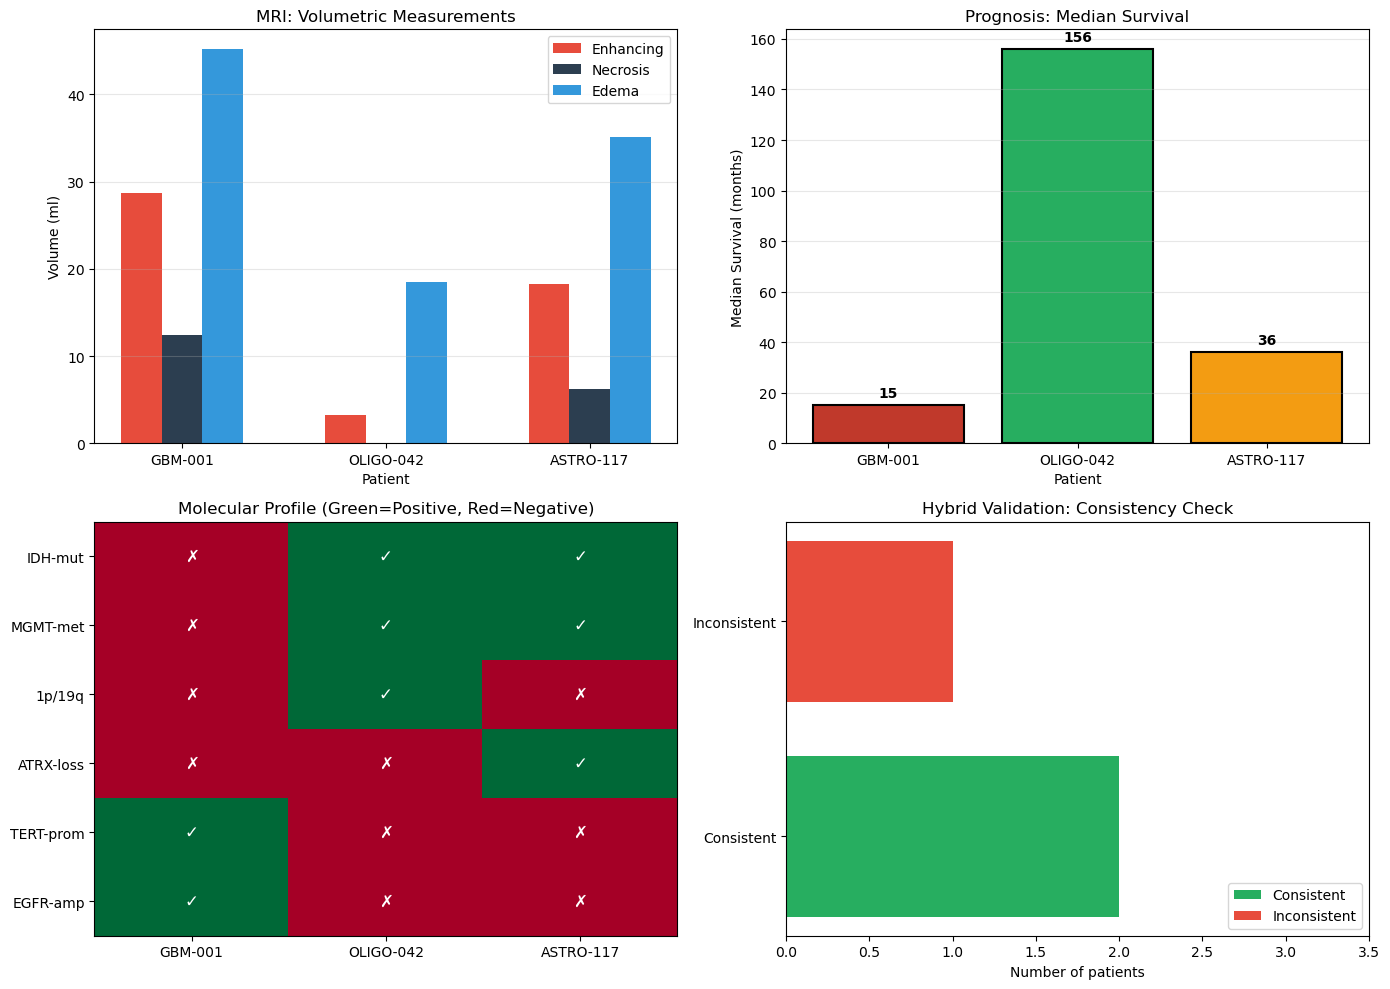


✓ Figure saved as 'glioma_analysis_comparison.png'


In [13]:
# ============================================================================
# VISUALIZATION: Comparison of Patients
# ============================================================================

import matplotlib.pyplot as plt

def visualize_patient_comparison(patients: List[GliomaPatient], 
                                      results: List[Dict]):
    """
    Visualizes and compares the three patient cases.
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # --- Plot 1: MRI volumetric features ---
    ax1 = axes[0, 0]
    x = np.arange(len(patients))
    width = 0.2
    
    enhancing = [p.mri.enhancing_volume_ml for p in patients]
    necrosis = [p.mri.necrosis_volume_ml for p in patients]
    edema = [p.mri.edema_volume_ml for p in patients]
    
    ax1.bar(x - width, enhancing, width, label='Enhancing', color='#e74c3c')
    ax1.bar(x, necrosis, width, label='Necrosis', color='#2c3e50')
    ax1.bar(x + width, edema, width, label='Edema', color='#3498db')
    
    ax1.set_ylabel('Volume (ml)')
    ax1.set_xlabel('Patient')
    ax1.set_title('MRI: Volumetric Measurements')
    ax1.set_xticks(x)
    ax1.set_xticklabels([p.patient_id for p in patients])
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)
    
    # --- Plot 2: Prognosis comparison ---
    ax2 = axes[0, 1]
    tumor_types = [r["symbolic_classification"]["tumor_type"] for r in results]
    survivals = []
    
    for tt in tumor_types:
        info = kg.tumor_types.get(tt, {})
        survivals.append(info.get("median_survival_months", 0))
    
    colors = ['#c0392b', '#27ae60', '#f39c12']
    bars = ax2.bar(x, survivals, color=colors, edgecolor='black', linewidth=1.5)
    
    ax2.set_ylabel('Median Survival (months)')
    ax2.set_xlabel('Patient')
    ax2.set_title('Prognosis: Median Survival')
    ax2.set_xticks(x)
    ax2.set_xticklabels([p.patient_id for p in patients])
    
    # Add values on bars
    for bar, val in zip(bars, survivals):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 f'{val:.0f}', ha='center', va='bottom', fontweight='bold')
    ax2.grid(axis='y', alpha=0.3)
    
    # --- Plot 3: Molecular profile as heatmap ---
    ax3 = axes[1, 0]
    
    profile_data = []
    for p in patients:
        mol = p.molecular
        profile_data.append([
            1 if mol.idh_status == IDHStatus.MUTANT else 0,
            1 if mol.mgmt_status == MGMTStatus.METHYLATED else 0,
            1 if mol.codeletion_1p19q else 0,
            1 if mol.atrx_loss else 0,
            1 if mol.tert_promoter else 0,
            1 if mol.egfr_amplification else 0
        ])
    
    profile_matrix = np.array(profile_data)
    im = ax3.imshow(profile_matrix.T, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
    
    ax3.set_yticks(range(6))
    ax3.set_yticklabels(['IDH-mut', 'MGMT-met', '1p/19q', 'ATRX-loss', 
                         'TERT-prom', 'EGFR-amp'])
    ax3.set_xticks(range(len(patients)))
    ax3.set_xticklabels([p.patient_id for p in patients])
    ax3.set_title('Molecular Profile (Green=Positive, Red=Negative)')
    
    # Add values in cells
    for i in range(len(patients)):
        for j in range(6):
            text = '✓' if profile_matrix[i, j] else '✗'
            ax3.text(i, j, text, ha='center', va='center', 
                     color='white', fontsize=12, fontweight='bold')
    
    # --- Plot 4: Validation status ---
    ax4 = axes[1, 1]
    
    # Prepare data
    categories = ['Consistent', 'Warnings']
    consistent = [1 if r["hybrid_validation"]["consistent"] else 0 for r in results]
    warnings = [len(r["hybrid_validation"]["warnings"]) for r in results]
    
    x_pos = np.arange(len(patients))
    
    ax4.barh([0], [sum(consistent)], color='#27ae60', label='Consistent', height=0.3)
    ax4.barh([0.4], [len(patients) - sum(consistent)], color='#e74c3c', 
             label='Inconsistent', height=0.3)
    
    ax4.set_xlim(0, len(patients) + 0.5)
    ax4.set_yticks([0, 0.4])
    ax4.set_yticklabels(['Consistent', 'Inconsistent'])
    ax4.set_xlabel('Number of patients')
    ax4.set_title('Hybrid Validation: Consistency Check')
    ax4.legend(loc='lower right')
    
    plt.tight_layout()
    plt.savefig('glioma_analysis_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\n✓ Figure saved as 'glioma_analysis_comparison.png'")

# Run visualization
visualize_patient_comparison(
    [patient_a, patient_b, patient_c],
    [result_a, result_b, result_c]
)

### Summary of Glioma Case Study

#### What Did We Demonstrate?

| Component | Technology | Function |
|-----------|-----------|----------|
| **Neural** | 3D U-Net, Radiogenomics | MRI segmentation, molecular prediction |
| **Symbolic** | Knowledge graph, Ontology | WHO classification, treatment rules |
| **Hybrid** | Consistency check | Validation, explanation |

#### Advantages of Neurosymbolic Approach for Glioma

1. **Explainability**: The clinician can follow the reasoning from MRI → Classification → Treatment
2. **Robustness**: Symbolic validation catches errors in neural predictions
3. **Updatability**: New WHO rules can easily be added to the knowledge graph
4. **Data scarcity**: Can leverage existing medical knowledge when data is limited

#### Clinical Relevance

- **Decision support**: Helps neurosurgeons and oncologists with complex classification
- **Quality assurance**: Automatic check of molecular-histological concordance
- **Prognosis**: Combines image-based and molecular biomarkers
- **Personalized treatment**: Stratification based on MGMT, IDH, etc.

#### Limitations and Future Directions

- **Data**: Requires validation on larger cohorts (e.g., TCGA, CGGA)
- **Uncertainty**: Better quantification of epistemic uncertainty
- **Integration**: Connection to electronic health records (EHR)
- **Learning**: Continuous updating based on new outcomes

### Agentic AI: Next Step for Clinical Decision Support

**Agentic AI** (agentic AI) represents a natural extension of neurosymbolic AI where the system can:
- **Act autonomously**: Take initiative for actions based on goals
- **Plan**: Break down complex tasks into sub-goals
- **Use tools**: Integrate with external systems and databases
- **Reason**: Reflect on own actions and adapt strategy
- **Learn**: Improve based on feedback

#### How Agentic AI Could Improve the Glioma System

In our neurosymbolic glioma system, an **AI agent** could orchestrate the entire workflow:

```
┌─────────────────────────────────────────────────────────────────────┐
│                     AGENTIC GLIOMA ASSISTANT                        │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│  PATIENT REFERRAL RECEIVED                                          │
│          ↓                                                          │
│  ┌─────────────────┐                                                │
│  │   AI-AGENT      │ ← Goal: "Give optimal treatment recommendation"│
│  └────────┬────────┘                                                │
│           │                                                         │
│  PLANNING: What steps are needed?                                   │
│           │                                                         │
│           ├──→ [1] Fetch MRI from PACS                              │
│           │         ↓                                               │
│           ├──→ [2] Run segmentation (nnU-Net)                       │
│           │         ↓                                               │
│           ├──→ [3] Fetch molecular test results from lab system     │
│           │         ↓                                               │
│           ├──→ [4] Classify tumor (WHO 2021)                        │
│           │         ↓                                               │
│           ├──→ [5] Search literature databases (PubMed, etc.)       │
│           │         ↓                                               │
│           ├──→ [6] Find similar patients in biobank                 │
│           │         ↓                                               │
│           ├──→ [7] Generate treatment recommendation                │
│           │         ↓                                               │
│           └──→ [8] Write report for MDT meeting                     │
│                                                                     │
│  REFLECTION: Is the result consistent? Do I need more info?         │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
```

#### Key Features of Agentic Glioma AI

| Feature | Description | Example |
|----------|-------------|----------|
| **Tool use** | Calls external APIs and systems | Fetches images from PACS, searches PubMed |
| **Planning** | Decomposes complex goals | "Classify tumor" → multiple sub-goals |
| **Memory** | Remembers previous interactions | Follow-up of same patient over time |
| **Reflection** | Evaluates own actions | "Is IDH prediction consistent with histology?" |
| **Human-in-the-loop** | Involves clinician when uncertain | "Uncertain classification - please verify" |

In [14]:
# ============================================================================
# AGENTIC AI: Simulated agent for glioma analysis
# ============================================================================

from abc import ABC, abstractmethod
from datetime import datetime
import time

class Tool(ABC):
    """Abstract base class for tools that the agent can use."""
    
    @property
    @abstractmethod
    def name(self) -> str:
        pass
    
    @property
    @abstractmethod
    def description(self) -> str:
        pass
    
    @abstractmethod
    def run(self, **kwargs) -> Dict:
        pass

class PACSTool(Tool):
    """Tool for fetching images from the PACS system."""
    
    @property
    def name(self) -> str:
        return "fetch_mri_from_pacs"
    
    @property
    def description(self) -> str:
        return "Fetches MRI images from the hospital PACS system based on patient ID"
    
    def run(self, patient_id: str) -> Dict:
        # Simulates API call to PACS
        print(f"    🔧 Connecting to PACS server...")
        time.sleep(0.3)
        print(f"    📥 Fetching MRI for patient {patient_id}...")
        return {
            "status": "success",
            "modalities": ["T1", "T1Gd", "T2", "FLAIR"],
            "number_of_series": 4,
            "date": "2024-01-15"
        }

class LiteratureSearchTool(Tool):
    """Tool for searching medical literature."""
    
    @property
    def name(self) -> str:
        return "search_pubmed"
    
    @property
    def description(self) -> str:
        return "Searches PubMed for relevant articles based on tumor type and markers"
    
    def run(self, tumor_type: str, markers: List[str]) -> Dict:
        print(f"    🔧 Searching PubMed for '{tumor_type}'...")
        time.sleep(0.3)
        # Simulated results
        return {
            "status": "success",
            "number_of_hits": 127,
            "top_articles": [
                {"title": "IDH mutations in gliomas: NEJM 2023", "relevance": 0.95},
                {"title": "MGMT methylation as predictor: Lancet Oncol 2024", "relevance": 0.91},
                {"title": "Novel treatment strategies: JCO 2024", "relevance": 0.88}
            ]
        }

class BiobankTool(Tool):
    """Tool for finding similar patients in biobank."""
    
    @property
    def name(self) -> str:
        return "search_biobank"
    
    @property
    def description(self) -> str:
        return "Finds similar patients in the biobank based on molecular profile"
    
    def run(self, molecular_profile: Dict) -> Dict:
        print(f"    🔧 Searching biobank for similar profiles...")
        time.sleep(0.3)
        return {
            "status": "success",
            "similar_patients": 23,
            "median_survival": 18.5,
            "treatment_response": {
                "temozolomide": 0.72,
                "radiation": 0.85
            }
        }

class AgentMemory:
    """Stores the agent's action history and observations."""
    
    def __init__(self):
        self.actions: List[Dict] = []
        self.observations: List[str] = []
        self.reflections: List[str] = []
    
    def log_action(self, action: str, result: Dict):
        self.actions.append({
            "timestamp": datetime.now().isoformat(),
            "action": action,
            "result": result
        })
    
    def log_observation(self, observation: str):
        self.observations.append(observation)
    
    def log_reflection(self, reflection: str):
        self.reflections.append(reflection)

class GliomaAgent:
    """
    Agentic AI system for glioma analysis.
    
    Combines:
    - Neurosymbolic reasoning (from earlier)
    - Tool use (PACS, PubMed, biobank)
    - Planning and reflection
    - Human-in-the-loop when uncertain
    """
    
    def __init__(self, ns_system: NeurosymbolicGliomaSystem):
        self.ns_system = ns_system
        self.tools = {
            "pacs": PACSTool(),
            "pubmed": LiteratureSearchTool(),
            "biobank": BiobankTool()
        }
        self.memory = AgentMemory()
        self.uncertainty_threshold = 0.7
    
    def plan(self, goal: str) -> List[str]:
        """Plans actions to achieve the goal."""
        print("\n📋 PLANNING")
        print("-" * 40)
        
        plan = [
            "1. Fetch MRI images from PACS",
            "2. Run neurosymbolic analysis",
            "3. Search for similar cases in biobank",
            "4. Find relevant literature",
            "5. Evaluate consistency",
            "6. Generate recommendation (or escalate to clinician)"
        ]
        
        print(f"  Goal: {goal}")
        print(f"  Plan:")
        for step in plan:
            print(f"    {step}")
        
        return plan
    
    def execute_plan(self, patient: GliomaPatient) -> Dict:
        """Executes the plan step by step with reflection."""
        
        goal = f"Give optimal treatment recommendation for patient {patient.patient_id}"
        plan = self.plan(goal)
        
        results = {}
        
        # Step 1: Fetch MRI
        print("\n🔄 STEP 1: Fetching MRI from PACS")
        print("-" * 40)
        pacs_result = self.tools["pacs"].run(patient_id=patient.patient_id)
        results["pacs"] = pacs_result
        self.memory.log_action("fetch_mri", pacs_result)
        print(f"    ✓ Received {pacs_result['number_of_series']} MRI series")
        
        # Step 2: Neurosymbolic analysis
        print("\n🔄 STEP 2: Running neurosymbolic analysis")
        print("-" * 40)
        ns_result = self.ns_system.analyze_patient(patient)
        results["neurosymbolic"] = ns_result
        self.memory.log_action("neurosymbolic_analysis", {"tumor_type": ns_result["symbolic_classification"]["tumor_type"]})
        
        # Step 3: Biobank search
        print("\n🔄 STEP 3: Searching biobank")
        print("-" * 40)
        biobank_result = self.tools["biobank"].run(
            molecular_profile={"idh": patient.molecular.idh_status.value}
        )
        results["biobank"] = biobank_result
        self.memory.log_action("biobank_search", biobank_result)
        print(f"    ✓ Found {biobank_result['similar_patients']} similar patients")
        
        # Step 4: Literature search
        print("\n🔄 STEP 4: Searching medical literature")
        print("-" * 40)
        tumor_type = ns_result["symbolic_classification"]["tumor_type"]
        pubmed_result = self.tools["pubmed"].run(
            tumor_type=tumor_type,
            markers=[patient.molecular.idh_status.value]
        )
        results["pubmed"] = pubmed_result
        self.memory.log_action("literature_search", pubmed_result)
        print(f"    ✓ Found {pubmed_result['number_of_hits']} relevant articles")
        
        # Step 5: Reflection
        print("\n🤔 STEP 5: Agent reflection")
        print("-" * 40)
        reflection = self.reflect(results)
        results["reflection"] = reflection
        
        # Step 6: Decision
        print("\n📊 STEP 6: Final recommendation")
        print("-" * 40)
        
        if reflection["needs_human_review"]:
            print("  ⚠️  ESCALATING TO CLINICIAN")
            print(f"      Reason: {reflection['escalation_reason']}")
            print("      → Recommend MDT discussion before treatment start")
        else:
            print("  ✓ Recommendation ready for clinical review")
            for tr in ns_result["treatment_recommendation"]["primary_treatment"]:
                print(f"      • {tr}")
        
        return results
    
    def reflect(self, results: Dict) -> Dict:
        """
        The agent reflects on its findings and assesses uncertainty.
        This is a core aspect of agentic AI.
        """
        reflection = {
            "observations": [],
            "uncertainty_assessment": "",
            "needs_human_review": False,
            "escalation_reason": None
        }
        
        # Check consistency in neurosymbolic analysis
        ns_res = results.get("neurosymbolic", {})
        if not ns_res.get("hybrid_validation", {}).get("consistent", True):
            reflection["observations"].append(
                "Inconsistency between neural predictions and symbolic classification"
            )
            reflection["needs_human_review"] = True
            reflection["escalation_reason"] = "Inconsistency in analysis - requires manual verification"
        
        # Check if biobank data supports recommendation
        biobank_res = results.get("biobank", {})
        if biobank_res.get("similar_patients", 0) < 10:
            reflection["observations"].append(
                "Few similar patients in biobank - limited evidence base"
            )
        
        # Check literature support
        pubmed_res = results.get("pubmed", {})
        if pubmed_res.get("top_articles"):
            highest_relevance = pubmed_res["top_articles"][0].get("relevance", 0)
            if highest_relevance < 0.8:
                reflection["observations"].append(
                    "Limited direct literature support for this profile"
                )
        
        # Summarize
        if reflection["needs_human_review"]:
            reflection["uncertainty_assessment"] = "HIGH - requires clinical review"
            print(f"  ⚠️  Uncertainty: {reflection['uncertainty_assessment']}")
        else:
            reflection["uncertainty_assessment"] = "MODERATE - recommendation can be presented"
            print(f"  ✓ Uncertainty: {reflection['uncertainty_assessment']}")
        
        for obs in reflection["observations"]:
            print(f"  → Observation: {obs}")
            self.memory.log_observation(obs)
        
        self.memory.log_reflection(reflection["uncertainty_assessment"])
        
        return reflection

print("✓ Agentic AI framework defined")
print("  - Tools: PACS, PubMed, Biobank")
print("  - Capabilities: Planning, Reflection, Human-in-the-loop")

✓ Agentic AI framework defined
  - Tools: PACS, PubMed, Biobank
  - Capabilities: Planning, Reflection, Human-in-the-loop


In [15]:
# ============================================================================
# DEMONSTRATION: Agentic Analysis of Glioma Patient
# ============================================================================

print("=" * 70)
print("AGENTIC GLIOMA ANALYSIS: Complete Workflow")
print("=" * 70)

# Create the agent
agent = GliomaAgent(ns_system)

# Run agent on patient C (the one with inconsistency - interesting for the agent!)
print("\n🤖 Starting agentic analysis of Patient C (ASTRO-117)")
print("   This patient has potential inconsistencies that the agent must handle\n")

agent_results = agent.execute_plan(patient_c)

# Show agent's memory
print("\n" + "=" * 70)
print("AGENT MEMORY (Action Log)")
print("=" * 70)
print(f"\nNumber of actions performed: {len(agent.memory.actions)}")
print(f"Number of observations: {len(agent.memory.observations)}")
print(f"Reflections: {agent.memory.reflections}")

AGENTIC GLIOMA ANALYSIS: Complete Workflow

🤖 Starting agentic analysis of Patient C (ASTRO-117)
   This patient has potential inconsistencies that the agent must handle


📋 PLANNING
----------------------------------------
  Goal: Give optimal treatment recommendation for patient ASTRO-117
  Plan:
    1. Fetch MRI images from PACS
    2. Run neurosymbolic analysis
    3. Search for similar cases in biobank
    4. Find relevant literature
    5. Evaluate consistency
    6. Generate recommendation (or escalate to clinician)

🔄 STEP 1: Fetching MRI from PACS
----------------------------------------
    🔧 Connecting to PACS server...
    📥 Fetching MRI for patient ASTRO-117...
    ✓ Received 4 MRI series

🔄 STEP 2: Running neurosymbolic analysis
----------------------------------------

NEUROSYMBOLIC ANALYSIS: Patient ASTRO-117

[STEP 1] NEURAL COMPONENT: MRI analysis
----------------------------------------
  Tumor volume: 48.7 ml
  Enhancing: 18.3 ml (37.6%)
  Necrosis: 6.2 ml
  Edema: 

### Summary: Agentic AI in Medicine

#### Advantages of Agentic Approach

| Aspect | Traditional AI | Agentic AI |
|--------|-----------------|-------------|
| **Workflow** | Single model call | Orchestrates multiple steps |
| **Tools** | None | Integrates with PACS, EHR, databases |
| **Uncertainty** | Passive reporting | Active escalation to clinician |
| **Context** | Stateless | Memory over time |
| **Adaptation** | Fixed pipeline | Dynamic planning |

#### Clinical Relevance

1. **Reduced cognitive load**: Agent handles routine tasks
2. **Quality assurance**: Automatic consistency check and literature support
3. **Documentation**: Full traceability of decision basis
4. **Scalability**: Can handle many patients in parallel

#### Challenges and Ethics

- **Responsibility**: Who is responsible when the agent makes a mistake?
- **Transparency**: Must be able to explain all actions
- **Control**: Human-in-the-loop is essential
- **Safety**: Must not perform harmful actions

#### Future Vision: LLM-based Medical Agents

With the emergence of large language models (LLM), medical agents can:
- Understand natural language from clinicians
- Reason about complex medical cases
- Generate structured reports
- Learn from feedback over time

> **Important**: Agentic AI in medicine must always operate under human supervision, 
> especially for critical decisions such as treatment choices.

In [16]:
# ============================================================================
# INTERACTIVE EXPLORATION: Create Your Own Patient
# ============================================================================

def create_random_patient(seed: int = None) -> GliomaPatient:
    """
    Generates a random glioma patient for exploration.
    Try changing the parameters and see how the classification changes!
    """
    if seed is not None:
        np.random.seed(seed)
    
    # Random molecular profile
    idh = np.random.choice([IDHStatus.WILDTYPE, IDHStatus.MUTANT], p=[0.4, 0.6])
    mgmt = np.random.choice([MGMTStatus.METHYLATED, MGMTStatus.UNMETHYLATED], p=[0.45, 0.55])
    
    # If IDH-mutant, determine subtype
    if idh == IDHStatus.MUTANT:
        is_oligo = np.random.choice([True, False], p=[0.35, 0.65])
    else:
        is_oligo = False
    
    molecular = MolecularProfile(
        idh_status=idh,
        mgmt_status=mgmt,
        codeletion_1p19q=is_oligo,
        atrx_loss=not is_oligo and idh == IDHStatus.MUTANT,
        tert_promoter=idh == IDHStatus.WILDTYPE and np.random.random() > 0.3,
        egfr_amplification=idh == IDHStatus.WILDTYPE and np.random.random() > 0.6
    )
    
    # Random MRI
    tumor_vol = np.random.uniform(15, 100)
    mri = MRIFeatures(
        tumor_volume_ml=round(tumor_vol, 1),
        enhancing_volume_ml=round(np.random.uniform(0, tumor_vol * 0.5), 1),
        necrosis_volume_ml=round(np.random.uniform(0, tumor_vol * 0.2), 1) if idh == IDHStatus.WILDTYPE else 0,
        edema_volume_ml=round(np.random.uniform(5, tumor_vol * 0.8), 1),
        location=np.random.choice(["frontal", "temporal", "parietal", "occipital"])
    )
    
    # Random clinical profile
    clinical = ClinicalProfile(
        age=np.random.randint(25, 80),
        karnofsky_score=np.random.choice([60, 70, 80, 90, 100]),
        symptom_duration_weeks=np.random.randint(2, 24)
    )
    
    return GliomaPatient(
        patient_id=f"RANDOM-{np.random.randint(1000, 9999)}",
        molecular=molecular,
        mri=mri,
        clinical=clinical
    )

# Generate and analyze a random patient
print("=" * 60)
print("GENERATING RANDOM PATIENT FOR EXPLORATION")
print("=" * 60)
print("\nTip: Run this cell multiple times to see different cases!")
print("Change the 'seed' parameter for reproducible results.\n")

random_patient = create_random_patient(seed=2024)
result_random = ns_system.analyze_patient(random_patient)

GENERATING RANDOM PATIENT FOR EXPLORATION

Tip: Run this cell multiple times to see different cases!
Change the 'seed' parameter for reproducible results.


NEUROSYMBOLIC ANALYSIS: Patient RANDOM-2532

[STEP 1] NEURAL COMPONENT: MRI analysis
----------------------------------------
  Tumor volume: 18.7 ml
  Enhancing: 1.9 ml (10.2%)
  Necrosis: 0 ml
  Edema: 6.1 ml
  Location: occipital

  Radiogenomics predictions:
    IDH-wildtype: 32% (uncertainty: moderate)
    MGMT-methylated: 59% (uncertainty: high)

[STEP 2] SYMBOLIC COMPONENT: WHO classification
----------------------------------------
  Applied rules:
    → IDH mutation detected
    → 1p/19q co-deletion detected → Oligodendroglioma
  Conclusion: Oligodendroglioma, grade 2

[STEP 3] HYBRID VALIDATION: Consistency check
----------------------------------------
  ✓ Neural predictions are CONSISTENT with symbolic classification

[STEP 4] TREATMENT RECOMMENDATION: Rule-based
----------------------------------------
  Primary treatm

---

## 7. Future Perspectives

### Why Neurosymbolic AI is Important for Medicine

1. **Explainability**: Symbolic knowledge provides meaningful explanations
2. **Robustness**: Ontologies catch errors and inconsistencies
3. **Data scarcity**: Can leverage existing medical knowledge
4. **Regulation**: Easier to verify and approve
5. **Trust**: Physicians understand the reasoning

### Active Research Areas

- Knowledge-enhanced LLMs (e.g., connecting GPT to SNOMED)
- Neural-symbolic reasoning in biomedical graphs
- Ontology learning from unstructured text
- Explanation of deep models via symbolic mapping

---

## Summary

### Key Points

1. **Two AI traditions**: Symbolic (interpretable, rule-based) vs. neural (learns from data)
2. **Neurosymbolic AI** combines the strengths of both approaches
3. **Knowledge graphs** represent medical knowledge as networks of entities and relations
4. **Ontologies** (SNOMED, ICD, WHO CNS classification) provide standardized vocabulary
5. **Hybrid systems** provide better explainability, robustness, and consistency checking
6. **Glioma case study** demonstrates practical neurosymbolic AI in neuro-oncology:
   - Neural component: MRI segmentation and radiogenomics
   - Symbolic component: WHO 2021 classification and treatment rules
   - Hybrid validation: Automatic detection of inconsistencies
7. **Agentic AI** extends neurosymbolic AI with:
   - Autonomous planning and action
   - Tool use (PACS, databases, literature search)
   - Reflection and human-in-the-loop when uncertain
   - Memory and contextual understanding over time

### Reflection Questions

1. **Knowledge graphs**: How could a knowledge graph improve an AI system you know?

2. **Medical domains**: Which other medical domains (beyond neuro-oncology) do you think would benefit most from neurosymbolic AI? Think about areas with:
   - Rich domain knowledge (ontologies, guidelines)
   - Need for explainability
   - Critical decisions

3. **Glioma case**: In the glioma case study, we saw that the system could detect inconsistencies between MRI features and molecular profile. Why is this clinically important?

4. **Regulation**: How can neurosymbolic AI make it easier to get medical AI software approved (e.g., as medical devices)?

5. **Challenges**: What do you see as the biggest challenges in implementing neurosymbolic AI in clinical practice?

6. **Agentic AI**: In the demonstration, we saw how an AI agent could orchestrate the entire workflow from MRI to treatment recommendation. What advantages and risks do you see with such autonomous systems in healthcare? When should the agent always escalate to a clinician?

---

### Further Reading

- [Neuro-Symbolic AI: The 3rd Wave](https://arxiv.org/abs/2012.05876) - Garcez & Lamb (2020)
- [WHO Classification of Tumours of the CNS, 5th Edition (2021)](https://tumourclassification.iarc.who.int/)
- [BraTS Challenge](https://www.synapse.org/brats) - Brain Tumor Segmentation
- [Knowledge Graphs in Healthcare](https://doi.org/10.1016/j.jbi.2020.103602) - Nicholson & Greene (2020)

---

*Next notebook: [09 - ChatGPT/Claude API](09-chatgpt-claude-api.ipynb)*